# 03. Modelagem e Avaliação

## Objetivo

A pergunta deste notebook é simples de enunciar: qual modelo, combinado com qual representação (PCA, UMAP ou TF-IDF) e qual dimensão, classifica melhor as categorias dos produtos?

In [1]:
import sys
import warnings

sys.path.append('../src')

import numpy as np
import pandas as pd
import scipy.sparse as sp

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.dummy import DummyClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score
)

from xgboost import XGBClassifier

import optuna

from preprocessing import carregar_e_limpar
from avaliacao import avaliar_modelo

warnings.filterwarnings('ignore')

optuna.logging.set_verbosity(optuna.logging.WARNING)

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = carregar_e_limpar('../data/raw/dataset_ecommerce.csv')

le = LabelEncoder()
y = le.fit_transform(df['categoria'])

idx = np.arange(len(df))
idx_train, idx_test, y_train, y_test = train_test_split(
    idx, y, test_size=0.2, random_state=42, stratify=y
)
texto_test = df['texto'].values[idx_test]

print(f"Treino: {len(idx_train)} | Teste: {len(idx_test)}")

Treino: 22241 | Teste: 5561


## 1. Baseline

Antes de treinar qualquer modelo de verdade, vale estabelecer uma referência simples: prever sempre a classe majoritária. Um modelo só é útil na prática se conseguir superar esse baseline.

In [3]:
baseline_data = np.load('../data/processed/embeddings_reducoes/pca_10.npz')
X_tr_base, X_te_base = baseline_data['X_train'], baseline_data['X_test']

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
metricas_baseline, y_pred_dummy = avaliar_modelo(
    'Baseline (classe majoritária)', dummy, X_tr_base, y_train, X_te_base, y_test
)
print("Baseline (prevê sempre a classe majoritária):")
for k, v in metricas_baseline.items():
    if k != 'modelo':
        print(f"  {k}: {v:.3f}")

Baseline (prevê sempre a classe majoritária):
  accuracy: 0.380
  balanced_accuracy: 0.250
  precision_macro: 0.095
  recall_macro: 0.250
  f1_macro: 0.138
  f1_weighted: 0.209


## 2 e 3. Modelos, PCA, UMAP e TF-IDF

Para essa comparação, escolhemos cinco modelos: a Logistic Regression, simples e linear, e quatro modelos baseados em árvores, com naturezas diferentes entre si. Random Forest e Extra Trees são exemplos de bagging, enquanto HistGradientBoosting e XGBoost são exemplos de boosting. Essa combinação vai de uma baseline linear até modelos mais complexos, o que ajuda a enxergar se a relação entre a representação do texto e a categoria é capturada melhor de forma linear ou não linear.

Testamos os cinco modelos com as representações salvas no notebook anterior: PCA e UMAP, cada uma nas três dimensões que definimos (10, 20 e 30), e o TF-IDF, em alta dimensão (5000 palavras, sem nenhuma redução). Uma exceção fica de fora: o HistGradientBoosting não aceita entrada esparsa nesta versão do scikit-learn (ele pede X denso), e densificar uma matriz TF-IDF de 5000 colunas custaria memória demais sem necessidade real, então essa combinação específica é pulada.

In [4]:
modelos = {
    'Logistic': LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=2
    ),

    'Extra Trees': ExtraTreesClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=2
    ),

    'HistGradientBoosting': HistGradientBoostingClassifier(
        random_state=42
    ),

    'XGBoost': XGBClassifier(
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=2
    )
}

reducoes_disponiveis = {
    'PCA': [10, 20, 30],
    'UMAP': [10, 20, 30],
    'TF-IDF': [5000]
}

resultados = []
predicoes_cache = {}
embeddings_cache = {}

for reducao, dims in reducoes_disponiveis.items():

    for dim in dims:

        if reducao == 'TF-IDF':
            # TF-IDF não passa pelo mesmo arquivo pca_*.npz / umap_*.npz:
            # ele é esparso, então foi salvo com scipy.sparse.save_npz
            # no notebook 02, em vez de np.savez.
            X_tr = sp.load_npz('../data/processed/embeddings_reducoes/tfidf_train.npz')
            X_te = sp.load_npz('../data/processed/embeddings_reducoes/tfidf_test.npz')
        else:
            dados = np.load(
                f'../data/processed/embeddings_reducoes/'
                f'{reducao.lower()}_{dim}.npz'
            )
            X_tr = dados['X_train']
            X_te = dados['X_test']

        embeddings_cache[(reducao, dim)] = (X_tr, X_te)

        for nome, modelo in modelos.items():

            if reducao == 'TF-IDF' and nome == 'HistGradientBoosting':
                print("[AVISO] HistGradientBoosting pulado para TF-IDF (não suporta entrada esparsa).")
                continue

            metricas, y_pred = avaliar_modelo(
                nome,
                modelo,
                X_tr,
                y_train,
                X_te,
                y_test
            )

            metricas.update({
                'reducao': reducao,
                'dim': dim
            })

            resultados.append(metricas)

            predicoes_cache[
                (reducao, dim, nome)
            ] = y_pred

[AVISO] HistGradientBoosting pulado para TF-IDF (não suporta entrada esparsa).


## Tabela comparativa

In [5]:
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados[['reducao', 'dim', 'modelo', 'accuracy', 'precision_macro',
                                'recall_macro', 'f1_macro', 'f1_weighted', 'balanced_accuracy']]
df_resultados = df_resultados.sort_values('f1_macro', ascending=False).reset_index(drop=True)
df_resultados

,reducao,dim,modelo,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,balanced_accuracy
0,TF-IDF,5000,Logistic,0.947671,0.950964,0.944030,0.947327,0.947598,0.944030
1,UMAP,10,Random Forest,0.937961,0.939099,0.937213,0.937790,0.937858,0.937213
2,UMAP,30,HistGradientBoosting,0.937421,0.938339,0.936811,0.937349,0.937374,0.936811
3,UMAP,10,Extra Trees,0.937062,0.938270,0.936228,0.936962,0.936953,0.936228
4,UMAP,30,Random Forest,0.936882,0.937204,0.937226,0.936903,0.936823,0.937226
5,UMAP,10,XGBoost,0.937062,0.938621,0.935709,0.936864,0.936960,0.935709
6,UMAP,20,XGBoost,0.936342,0.937261,0.935073,0.935817,0.936245,0.935073
7,UMAP,20,Extra Trees,0.935803,0.936489,0.934942,0.935307,0.935716,0.934942
8,TF-IDF,5000,Extra Trees,0.935084,0.941367,0.929882,0.935065,0.934903,0.929882
9,UMAP,10,HistGradientBoosting,0.935084,0.936353,0.934311,0.935025,0.934979,0.934311


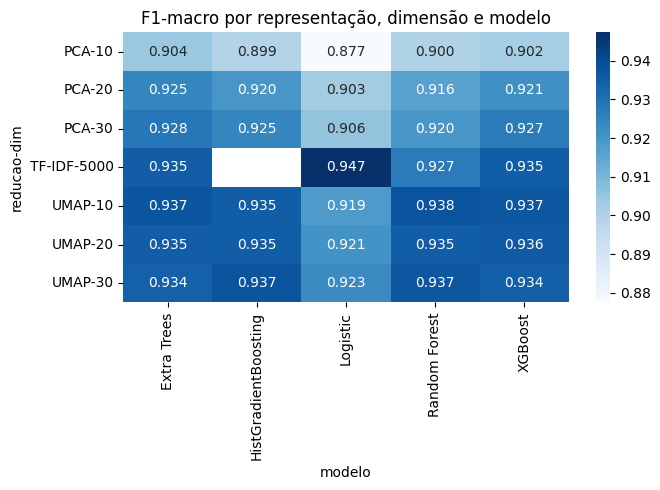

Melhor combinação geral: TF-IDF 5000D + Logistic (F1-macro=0.947)
Ganho sobre o baseline: 0.810 em F1-macro


In [6]:
pivot = df_resultados.pivot_table(index=['reducao', 'dim'], columns='modelo', values='f1_macro')
plt.figure(figsize=(7, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='Blues')
plt.title('F1-macro por representação, dimensão e modelo')
plt.tight_layout()
plt.show()

melhor = df_resultados.iloc[0]
melhor_reducao, melhor_dim, melhor_modelo = melhor['reducao'], int(melhor['dim']), melhor['modelo']
print(f"Melhor combinação geral: {melhor_reducao} {melhor_dim}D + {melhor_modelo} (F1-macro={melhor['f1_macro']:.3f})")
print(f"Ganho sobre o baseline: {melhor['f1_macro'] - metricas_baseline['f1_macro']:.3f} em F1-macro")

## 4. Escolhendo as configurações para otimizar

A decisão de otimizar o XGBoost com Optuna foi uma escolha do projeto, não uma exigência do case. Faz sentido então otimizar também o candidato que teve o melhor resultado geral na tabela acima, TF-IDF + Logistic Regression, para comparar os dois em pé de igualdade (ambos com hiperparâmetros ajustados) e deixar o notebook final usar quem realmente vencer, e não quem foi escolhido antes de rodar a comparação.

Por isso, selecionamos aqui duas configurações: a melhor linha em que o modelo é XGBoost, e a melhor linha em que o modelo é Logistic Regression.

In [7]:
resultados_xgb = df_resultados[df_resultados['modelo'] == 'XGBoost'].sort_values('f1_macro', ascending=False)
melhor_xgb = resultados_xgb.iloc[0]
xgb_reducao, xgb_dim = melhor_xgb['reducao'], int(melhor_xgb['dim'])
print(f"Melhor configuração para XGBoost: {xgb_reducao} {xgb_dim}D (F1-macro={melhor_xgb['f1_macro']:.3f})")

X_tr_xgb, X_te_xgb = embeddings_cache[(xgb_reducao, xgb_dim)]

resultados_log = df_resultados[df_resultados['modelo'] == 'Logistic'].sort_values('f1_macro', ascending=False)
melhor_log = resultados_log.iloc[0]
log_reducao, log_dim = melhor_log['reducao'], int(melhor_log['dim'])
print(f"Melhor configuração para Logistic Regression: {log_reducao} {log_dim}D (F1-macro={melhor_log['f1_macro']:.3f})")

X_tr_log, X_te_log = embeddings_cache[(log_reducao, log_dim)]

Melhor configuração para XGBoost: UMAP 10D (F1-macro=0.937)
Melhor configuração para Logistic Regression: TF-IDF 5000D (F1-macro=0.947)


## 5. Otimização com Optuna

Para não usar o conjunto de teste durante a busca de hiperparâmetros, o que seria um vazamento de dados, separamos uma fatia de validação dentro do próprio treino. Os mesmos índices de treino/validação são usados para os dois modelos, então a comparação entre eles fica justa.

Duas buscas são feitas: uma para o XGBoost (número de árvores, profundidade, taxa de aprendizado, entre outros), e outra para a Logistic Regression (força da regularização `C` e se as classes devem ter peso balanceado).

In [8]:
idx_tr_train, idx_tr_val = train_test_split(
    np.arange(len(y_train)), test_size=0.2, random_state=42, stratify=y_train
)
y_opt_train, y_opt_val = y_train[idx_tr_train], y_train[idx_tr_val]

X_opt_train_xgb, X_opt_val_xgb = X_tr_xgb[idx_tr_train], X_tr_xgb[idx_tr_val]
X_opt_train_log, X_opt_val_log = X_tr_log[idx_tr_train], X_tr_log[idx_tr_val]

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'eval_metric': 'mlogloss', 'random_state': 42, 'n_jobs': 2,
    }
    modelo = XGBClassifier(**params)
    modelo.fit(X_opt_train_xgb, y_opt_train)
    y_pred = modelo.predict(X_opt_val_xgb)
    return f1_score(y_opt_val, y_pred, average='macro')

study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=25)

melhores_params_xgb = study_xgb.best_params.copy()
melhores_params_xgb.update({'eval_metric': 'mlogloss', 'random_state': 42, 'n_jobs': 2})

print(f"[XGBoost] Configuração: {xgb_reducao} {xgb_dim}D")
print(f"[XGBoost] Melhor F1-macro (validação): {study_xgb.best_value:.3f}")
print(f"[XGBoost] Melhores hiperparâmetros: {study_xgb.best_params}")


def objective_logistic(trial):
    params = {
        'C': trial.suggest_float('C', 1e-3, 1e2, log=True),
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
        'max_iter': 2000,
        'random_state': 42,
    }
    modelo = LogisticRegression(**params)
    modelo.fit(X_opt_train_log, y_opt_train)
    y_pred = modelo.predict(X_opt_val_log)
    return f1_score(y_opt_val, y_pred, average='macro')

study_log = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_log.optimize(objective_logistic, n_trials=25)

melhores_params_log = study_log.best_params.copy()
melhores_params_log.update({'max_iter': 2000, 'random_state': 42})

print(f"\n[Logistic] Configuração: {log_reducao} {log_dim}D")
print(f"[Logistic] Melhor F1-macro (validação): {study_log.best_value:.3f}")
print(f"[Logistic] Melhores hiperparâmetros: {study_log.best_params}")

[XGBoost] Configuração: UMAP 10D
[XGBoost] Melhor F1-macro (validação): 0.948
[XGBoost] Melhores hiperparâmetros: {'n_estimators': 450, 'max_depth': 7, 'learning_rate': 0.05559677900924592, 'subsample': 0.7203293152524058, 'colsample_bytree': 0.798834157444341, 'min_child_weight': 8}



[Logistic] Configuração: TF-IDF 5000D
[Logistic] Melhor F1-macro (validação): 0.952
[Logistic] Melhores hiperparâmetros: {'C': 5.179554356516547, 'class_weight': 'balanced'}


## 6. Validação cruzada (5-fold)

Aplicada aos dois finalistas otimizados, cada um na sua própria representação, para ver o quanto o resultado de cada um se mantém estável entre folds diferentes.

5-fold CV — XGBoost otimizado (UMAP 10D):
  f1_macro         média=0.947 +/- 0.002 | valores=[0.945 0.946 0.947 0.95  0.949]
  accuracy         média=0.947 +/- 0.001 | valores=[0.946 0.946 0.947 0.949 0.949]
  precision_macro  média=0.949 +/- 0.001 | valores=[0.947 0.95  0.948 0.951 0.95 ]
  recall_macro     média=0.945 +/- 0.002 | valores=[0.944 0.942 0.945 0.949 0.947]

5-fold CV — Logistic Regression otimizada (TF-IDF 5000D):
  f1_macro         média=0.946 +/- 0.003 | valores=[0.947 0.942 0.949 0.949 0.944]
  accuracy         média=0.947 +/- 0.003 | valores=[0.947 0.942 0.949 0.95  0.945]
  precision_macro  média=0.946 +/- 0.003 | valores=[0.947 0.942 0.948 0.949 0.944]
  recall_macro     média=0.946 +/- 0.003 | valores=[0.947 0.941 0.95  0.949 0.944]


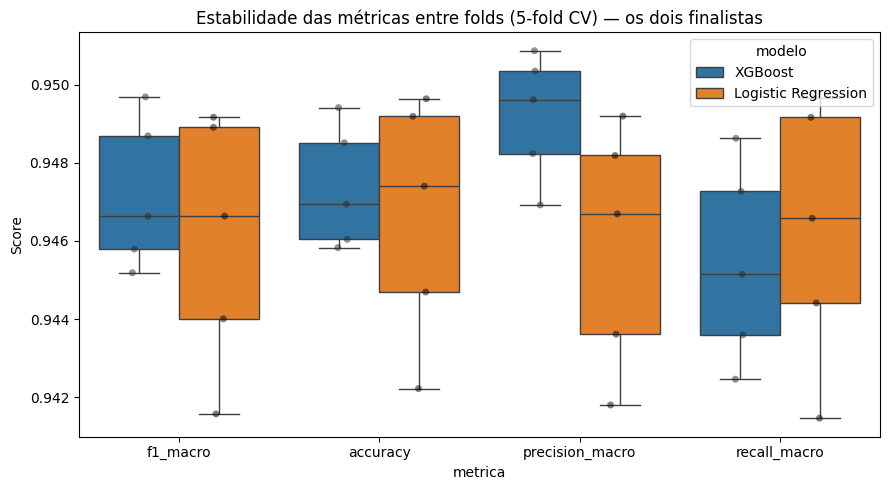

In [9]:
scoring = {'f1_macro': 'f1_macro', 'accuracy': 'accuracy', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelo_cv_xgb = XGBClassifier(**melhores_params_xgb)
scores_cv_xgb = cross_validate(modelo_cv_xgb, X_tr_xgb, y_train, cv=skf, scoring=scoring)

modelo_cv_log = LogisticRegression(**melhores_params_log)
scores_cv_log = cross_validate(modelo_cv_log, X_tr_log, y_train, cv=skf, scoring=scoring)

print(f"5-fold CV — XGBoost otimizado ({xgb_reducao} {xgb_dim}D):")
for metrica in scoring:
    vals = scores_cv_xgb[f'test_{metrica}']
    print(f"  {metrica:16s} média={vals.mean():.3f} +/- {vals.std():.3f} | valores={np.round(vals, 3)}")

print(f"\n5-fold CV — Logistic Regression otimizada ({log_reducao} {log_dim}D):")
for metrica in scoring:
    vals = scores_cv_log[f'test_{metrica}']
    print(f"  {metrica:16s} média={vals.mean():.3f} +/- {vals.std():.3f} | valores={np.round(vals, 3)}")

dados_cv_xgb = pd.DataFrame({m: scores_cv_xgb[f'test_{m}'] for m in scoring})
dados_cv_xgb['modelo'] = 'XGBoost'
dados_cv_log = pd.DataFrame({m: scores_cv_log[f'test_{m}'] for m in scoring})
dados_cv_log['modelo'] = 'Logistic Regression'
dados_cv = pd.concat([dados_cv_xgb, dados_cv_log], ignore_index=True)
dados_cv_long = dados_cv.melt(id_vars='modelo', var_name='metrica', value_name='score')

plt.figure(figsize=(9, 5))
sns.boxplot(data=dados_cv_long, x='metrica', y='score', hue='modelo')
sns.stripplot(data=dados_cv_long, x='metrica', y='score', hue='modelo', dodge=True, color='black', alpha=0.5, legend=False)
plt.title('Estabilidade das métricas entre folds (5-fold CV) — os dois finalistas')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

## 7. Avaliação final no teste

Os dois finalistas otimizados são treinados no treino completo e avaliados no teste. O que tiver o maior F1-macro no teste é o vencedor, e é essa configuração que segue para as análises abaixo e para o notebook final.

XGBoost otimizado   (UMAP 10D) — F1 macro: 0.938 | F1 weighted: 0.938 | ROC-AUC: 0.985
Logistic otimizada  (TF-IDF 5000D) — F1 macro: 0.949 | F1 weighted: 0.950 | ROC-AUC: 0.991

Vencedor: Logistic Regression (TF-IDF 5000D), F1-macro=0.949

                      precision    recall  f1-score   support

               Books       0.94      0.93      0.94      1251
Clothing_Accessories       0.97      0.98      0.98      1135
         Electronics       0.93      0.93      0.93      1062
           Household       0.95      0.95      0.95      2113

            accuracy                           0.95      5561
           macro avg       0.95      0.95      0.95      5561
        weighted avg       0.95      0.95      0.95      5561



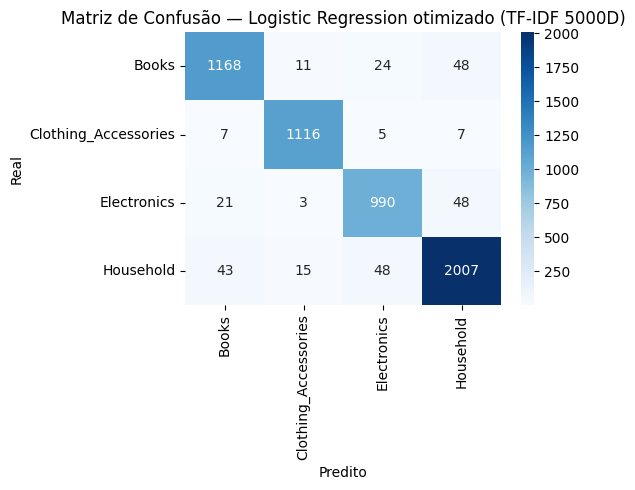

In [10]:
xgb_final = XGBClassifier(**melhores_params_xgb)
xgb_final.fit(X_tr_xgb, y_train)
y_pred_xgb = xgb_final.predict(X_te_xgb)
y_proba_xgb = xgb_final.predict_proba(X_te_xgb)

f1_macro_xgb = f1_score(y_test, y_pred_xgb, average='macro')
f1_weighted_xgb = f1_score(y_test, y_pred_xgb, average='weighted')
roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb, multi_class='ovr', average='macro')

log_final = LogisticRegression(**melhores_params_log)
log_final.fit(X_tr_log, y_train)
y_pred_log = log_final.predict(X_te_log)
y_proba_log = log_final.predict_proba(X_te_log)

f1_macro_log = f1_score(y_test, y_pred_log, average='macro')
f1_weighted_log = f1_score(y_test, y_pred_log, average='weighted')
roc_auc_log = roc_auc_score(y_test, y_proba_log, multi_class='ovr', average='macro')

print(f"XGBoost otimizado   ({xgb_reducao} {xgb_dim}D) — F1 macro: {f1_macro_xgb:.3f} | F1 weighted: {f1_weighted_xgb:.3f} | ROC-AUC: {roc_auc_xgb:.3f}")
print(f"Logistic otimizada  ({log_reducao} {log_dim}D) — F1 macro: {f1_macro_log:.3f} | F1 weighted: {f1_weighted_log:.3f} | ROC-AUC: {roc_auc_log:.3f}")

if f1_macro_xgb >= f1_macro_log:
    modelo_final_nome = 'XGBoost'
    reducao_final, dim_final = xgb_reducao, xgb_dim
    params_finais = melhores_params_xgb
    y_pred_final, y_proba_final = y_pred_xgb, y_proba_xgb
    f1_macro_final, f1_weighted_final, roc_auc_final = f1_macro_xgb, f1_weighted_xgb, roc_auc_xgb
else:
    modelo_final_nome = 'Logistic Regression'
    reducao_final, dim_final = log_reducao, log_dim
    params_finais = melhores_params_log
    y_pred_final, y_proba_final = y_pred_log, y_proba_log
    f1_macro_final, f1_weighted_final, roc_auc_final = f1_macro_log, f1_weighted_log, roc_auc_log

print(f"\nVencedor: {modelo_final_nome} ({reducao_final} {dim_final}D), F1-macro={f1_macro_final:.3f}")

print()
print(classification_report(y_test, y_pred_final, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Matriz de Confusão — {modelo_final_nome} otimizado ({reducao_final} {dim_final}D)')
plt.ylabel('Real')
plt.xlabel('Predito')
plt.tight_layout()
plt.show()

## 8. Análise dos erros

In [11]:
erros = pd.DataFrame({
    'texto': [t[:120] for t in texto_test],
    'categoria_real': le.inverse_transform(y_test),
    'categoria_prevista': le.inverse_transform(y_pred_final),
})
erros_apenas = erros[erros['categoria_real'] != erros['categoria_prevista']]
print(f"Total de erros: {len(erros_apenas)} de {len(erros)} ({len(erros_apenas) / len(erros) * 100:.1f}%)")
display(erros_apenas.sample(min(10, len(erros_apenas)), random_state=42))

Total de erros: 280 de 5561 (5.0%)


,texto,categoria_real,categoria_prevista
654,SR Global Spy Hd Pen Camera with Voice-Video R...,Electronics,Household
1936,RRG Cotton Durry/Durrie/Rug Block Print (4X6 F...,Household,Clothing_Accessories
4831,WISSEN Wooden Transportation knob Puzzle Tray ...,Books,Household
5125,Candlestick Accent Light in Blackened Tin Cand...,Household,Books
2767,Kauberi Jewels 12pcs Bridal Wedding Prom Silve...,Household,Clothing_Accessories
279,INSPIRED : HOW TO CREATE TECH PRODUCTS CUSTOME...,Books,Household
2686,"Tool Point Silicon Waves Analogue Circuit AC, ...",Household,Electronics
3875,Charms Anklet for Women (Silver)(CR0251-285ef)...,Household,Clothing_Accessories
2627,Hoover Genuine Purepower Dustmanager Whirlwind...,Household,Books
2785,DOCOSS Waterproof Cree Bright Zoom LED Torches...,Household,Electronics


In [12]:
pares_confusao = (
    erros_apenas.groupby(['categoria_real', 'categoria_prevista'])
    .size()
    .reset_index(name='quantidade')
    .sort_values('quantidade', ascending=False)
)
print("Pares de categorias mais confundidos:")
display(pares_confusao.head(10))

Pares de categorias mais confundidos:


,categoria_real,categoria_prevista,quantidade
2,Books,Household,48
11,Household,Electronics,48
8,Electronics,Household,48
9,Household,Books,43
1,Books,Electronics,24
6,Electronics,Books,21
10,Household,Clothing_Accessories,15
0,Books,Clothing_Accessories,11
3,Clothing_Accessories,Books,7
5,Clothing_Accessories,Household,7


## Fechamento

Com os dois finalistas otimizados por Optuna, a Logistic Regression com TF-IDF (5000D) venceu no teste: F1-macro de 0,949, contra 0,938 do XGBoost otimizado com UMAP (10D). A diferença já aparecia sem ajuste de hiperparâmetros, e se manteve depois que os dois passaram pela mesma busca de 25 trials.

Isso confirma o que a tabela comparativa já sugeria: para esse problema, a representação clássica (contagem de palavras ponderada) junto com um modelo linear simples captura a relação entre texto e categoria pelo menos tão bem quanto os embeddings de frase reduzidos por UMAP e um modelo de árvores mais complexo como o XGBoost. Uma hipótese razoável é que as categorias aqui se distinguem bastante por vocabulário específico (palavras que aparecem quase só em produtos de uma categoria), e é exatamente esse tipo de sinal que o TF-IDF captura bem, mesmo sem entender o significado das palavras como um embedding faz.

A validação cruzada mostra que os dois modelos são igualmente estáveis entre folds (desvio padrão pequeno nos dois casos), e a análise de erros aponta as mesmas confusões de sempre entre Household e as demais categorias, o que sugere que o gargalo está mais na sobreposição de vocabulário entre certas categorias do que na escolha do modelo.

É a configuração vencedora, TF-IDF + Logistic Regression, com os hiperparâmetros encontrados pelo Optuna, que vamos usar no notebook final, `04_modelo_final_conclusao.ipynb`.